In [3]:
import numpy as np

# Parameters
m = 2
oneoverm = 1. / m
heat_capacity_ratio = 1e3

# Grid setup
N = 50
beta_d_grid = np.logspace(-6, 3, N)
beta_r_grid = np.logspace(-6, 3, N)

shift_Td = np.zeros((N, N))
amp_Td = np.zeros((N, N))
shift_Tg = np.zeros((N, N))
amp_Tg = np.zeros((N, N))

for i, beta_d in enumerate(beta_d_grid):
    for j, beta_r in enumerate(beta_r_grid):
        beta_g = heat_capacity_ratio * beta_d
        beta_sum = 1. / (1. / beta_g + 1. / beta_d + 1. / beta_r)
        
        D2 = (1 - beta_g * beta_r / oneoverm**2)**2 + (beta_g / oneoverm * beta_r / beta_sum)**2
        Td_real = 1 - beta_g * beta_r / oneoverm**2 + (beta_g / oneoverm)**2 * (beta_r / beta_sum)
        Td_imag = beta_g / oneoverm - (beta_g / oneoverm)**2 * beta_r / oneoverm - beta_g / oneoverm * beta_r / beta_sum

        Tg_real = 1. - beta_g * beta_r / oneoverm**2
        Tg_imag = -beta_g / oneoverm * (beta_r / beta_sum)

        Td_cplx = Td_real + 1j * Td_imag
        Tg_cplx = Tg_real + 1j * Tg_imag

        shift_Td[i, j] = np.angle(Td_cplx) / m
        amp_Td[i, j] = np.abs(Td_cplx) / D2

        shift_Tg[i, j] = np.angle(Tg_cplx) / m
        amp_Tg[i, j] = np.abs(Tg_cplx) / D2


#shift_Td[amp_Td < 1e-1] = np.nan
#shift_Tg[amp_Tg < 1e-1] = np.nan

#shift_Td[-shift_Td < np.deg2rad(4.5)] = np.nan
#shift_Tg[-shift_Tg < np.deg2rad(4.5)] = np.nan

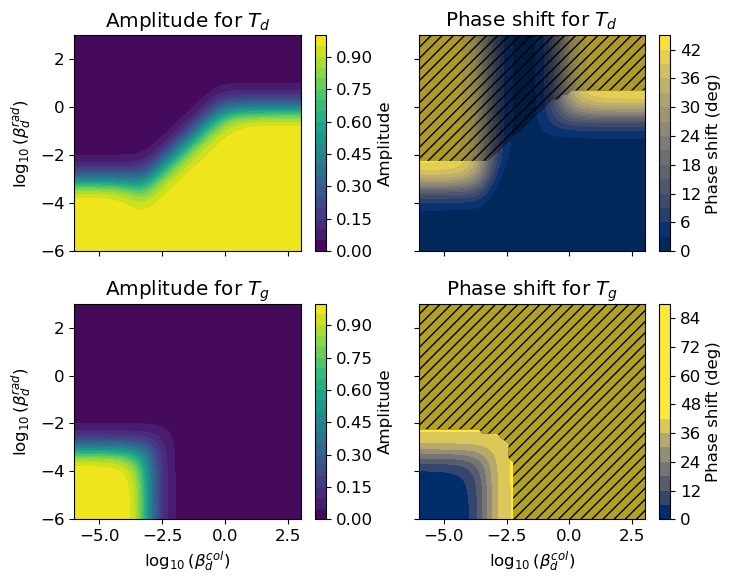

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.rc("font", size=12)
fig, axes = plt.subplots(2, 2, figsize=(7.5, 6), sharex=True, sharey=True)

# Panel 1: Amplitude for Td
im0 = axes[0, 0].contourf(
    np.log10(beta_d_grid), np.log10(beta_r_grid), amp_Td.T, levels=21, cmap='viridis',
    vmax=1, vmin=0
)
axes[0, 0].set_title('Amplitude for $T_d$')
fig.colorbar(im0, ax=axes[0, 0], label='Amplitude')

# Panel 2: Phase shift for Td
im1 = axes[0, 1].contourf(
    np.log10(beta_d_grid), np.log10(beta_r_grid), -np.rad2deg(shift_Td.T),
      levels=int(90/m/3)+1, vmax=90/m, vmin=0, cmap='cividis'
)
axes[0, 1].set_title('Phase shift for $T_d$')
fig.colorbar(im1, ax=axes[0, 1], label='Phase shift (deg)')

# Panel 3: Amplitude for Tg
im2 = axes[1, 0].contourf(
    np.log10(beta_d_grid), np.log10(beta_r_grid), amp_Tg.T, levels=21, cmap='viridis',
    vmax=1, vmin=0
)
axes[1, 0].set_title('Amplitude for $T_g$')
fig.colorbar(im2, ax=axes[1, 0], label='Amplitude')

# Panel 4: Phase shift for Tg
im3 = axes[1, 1].contourf(
    np.log10(beta_d_grid), np.log10(beta_r_grid), -np.rad2deg(shift_Tg.T), 
    levels=int(90/m/3)+1, vmax=90/m, vmin=0, cmap='cividis'
)
axes[1, 1].set_title('Phase shift for $T_g$')
fig.colorbar(im3, ax=axes[1, 1], label='Phase shift (deg)')

for ax in axes[1, :]:
    ax.set_xlabel(r'$\log_{10}(\beta_d^{col})$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\log_{10}(\beta_d^{rad})$')

#---------
import numpy as np
import matplotlib.pyplot as plt

# assume beta_d_grid, beta_r_grid, amp_Tg, axes already exist like in your notebook
# if not, recreate minimal example:
# X = np.log10(beta_d_grid); Y = np.log10(beta_r_grid)

# build boolean mask where amplitude is small
mask = (amp_Tg.T < 1e-1).astype(int)   # .T because you plotted amp_Tg.T previously

# overlay hatch on the Tg phase panel (axes[1,1] in your layout)
ax = axes[1, 1]

# draw hatch only where mask==1
# choose levels that select the 1 region: [0.5, 1.5]
h = ax.contourf(
    np.log10(beta_d_grid), np.log10(beta_r_grid), mask,
    levels=[0.5, 1.5],
    colors='none',            # transparent face so underlying colormap shows
    hatches=['///'],         # choose hatch style
    alpha=0.3                  # ensure only hatch is visible
)


# build boolean mask where amplitude is small
mask = (amp_Td.T < 1e-1).astype(int)   # .T because you plotted amp_Tg.T previously

# overlay hatch on the Tg phase panel (axes[1,1] in your layout)
ax = axes[0, 1]

# draw hatch only where mask==1
# choose levels that select the 1 region: [0.5, 1.5]
h = ax.contourf(
    np.log10(beta_d_grid), np.log10(beta_r_grid), mask,
    levels=[0.5, 1.5],
    colors='none',            # transparent face so underlying colormap shows
    hatches=['///'],         # choose hatch style
    alpha=0.3                 # ensure only hatch is visible
)

# if you want the hatch to be lighter/darker, remove alpha=0 and set facecolor to a partially transparent color:
# ax.contourf(..., levels=[0.5,1.5], colors=[(1,1,1,0.0)], hatches=['///'])

plt.draw()

plt.tight_layout()
plt.show()

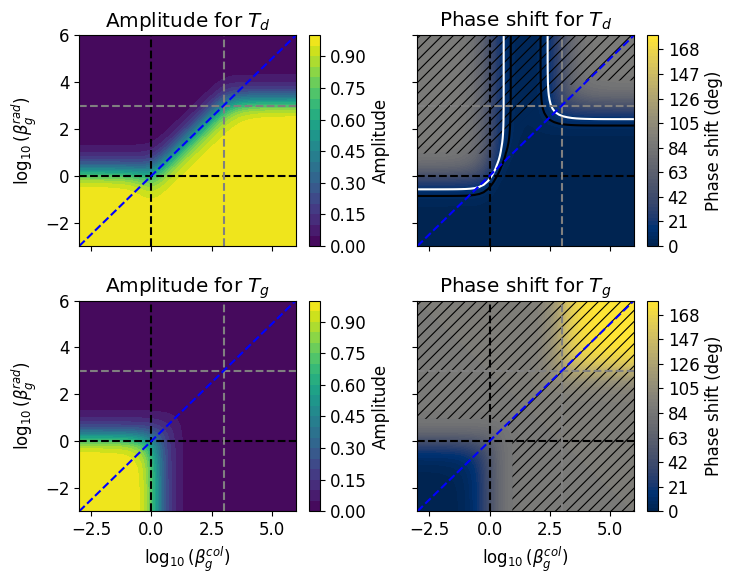

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.rc("font", size=12)
plt.rcParams['hatch.color'] = 'k'
plt.rcParams['hatch.linewidth'] = 0.8

fig, axes = plt.subplots(2, 2, figsize=(7.5, 6), sharex=True, sharey=True)

x = np.log10(beta_d_grid * heat_capacity_ratio)
y = np.log10(beta_r_grid * heat_capacity_ratio)

# Panel 1: Amplitude for Td
im0 = axes[0, 0].contourf(
    x, y, amp_Td.T, levels=21, cmap='viridis', vmax=1, vmin=0
)
axes[0, 0].set_title('Amplitude for $T_d$')
fig.colorbar(im0, ax=axes[0, 0], label='Amplitude')

# Panel 2: Phase shift for Td
im1 = axes[0, 1].contourf(
    x, y, (-np.rad2deg(shift_Td.T)),
    levels=np.linspace(0, 180, int(180 / 3) + 1), cmap='cividis'
)

axes[0, 1].contour(
    x, y, (-np.rad2deg(shift_Td.T)), levels=[8, 15], cmap='gray'
)

axes[0, 1].set_title('Phase shift for $T_d$')
fig.colorbar(im1, ax=axes[0, 1], label='Phase shift (deg)')

# Panel 3: Amplitude for Tg
im2 = axes[1, 0].contourf(
    x, y, amp_Tg.T, levels=21, cmap='viridis', vmax=1, vmin=0
)
axes[1, 0].set_title('Amplitude for $T_g$')
fig.colorbar(im2, ax=axes[1, 0], label='Amplitude')

# Panel 4: Phase shift for Tg
im3 = axes[1, 1].contourf(
    x, y, (-np.rad2deg(shift_Tg.T)),
    levels=np.linspace(0, 180, int(180 / 3) + 1), cmap='cividis'
)
axes[1, 1].set_title('Phase shift for $T_g$')
fig.colorbar(im3, ax=axes[1, 1], label='Phase shift (deg)')

for ax in axes[1, :]:
    ax.set_xlabel(r'$\log_{10}(\beta_g^{col})$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\log_{10}(\beta_g^{rad})$')

for ax in axes.flatten():
    ax.axvline(0, color='k', linestyle='--')
    ax.axhline(0, color='k', linestyle='--')
    ax.axvline(np.log10(heat_capacity_ratio), color='gray', linestyle='--')
    ax.axhline(np.log10(heat_capacity_ratio), color='gray', linestyle='--')
    ax.plot([-3, 6], [-3, 6], color='blue', linestyle='--')


def add_hatch_overlay(ax, data_mask):
    # Avoid alpha for hatch overlays; vector backends can drop faint hatch strokes.
    ax.contourf(
        x, y, data_mask,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['///']
    )


# Overlay hatch where amplitude is small
add_hatch_overlay(axes[1, 1], (amp_Tg.T < 1e-1).astype(int))
add_hatch_overlay(axes[0, 1], (amp_Td.T < 1e-1).astype(int))

plt.tight_layout()
plt.savefig(
    '2Dmap_Td_Tg_example_heat_capacity_ratio_1e3_m2.pdf',
    dpi=300,
    bbox_inches='tight',
    transparent=False
)
plt.show()

In [7]:
int(90/m/3)+1

16

In [ ]:
f
ff-np.rad2deg(shift_Tg.T)

array([[ 1.14536227,  1.40631066,  1.78591346, ..., 45.00002692,
        45.00003644, 45.00004297],
       [ 1.40633675,  1.6670518 ,  2.04623827, ..., 45.00005306,
        45.00006258, 45.00006912],
       [ 1.78597743,  2.04627616,  2.42474583, ..., 45.00009114,
        45.00010066, 45.0001072 ],
       ...,
       [45.00002691, 45.00005306, 45.00009113, ..., 89.39245304,
        89.48762339, 89.55297867],
       [45.00003643, 45.00006258, 45.00010065, ..., 89.48761387,
        89.58279553, 89.64815736],
       [45.00004297, 45.00006911, 45.00010719, ..., 89.55296262,
        89.64815083, 89.71351633]])

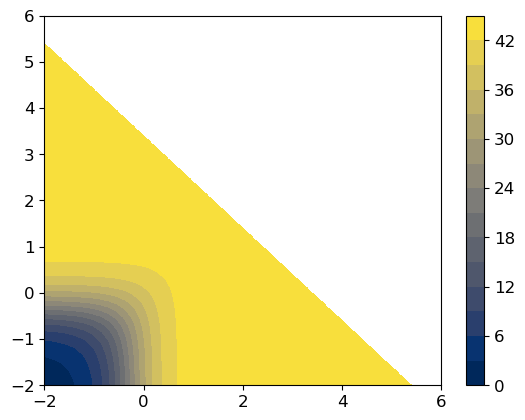

In [16]:
plt.contourf(
    np.log10(beta_d_grid*heat_capacity_ratio), np.log10(beta_r_grid*heat_capacity_ratio), (-np.rad2deg(shift_Tg.T)), 
      cmap='cividis', levels = np.linspace(0, 90/m, int(90/m/3)+1))
plt.colorbar()

In [24]:
int(90/m/3)+1

16

In [28]:
# ...existing code...
import numpy as np

def compute_T_shifts_and_amps(m, heat_capacity_ratio, beta_col_d, beta_rad_d, mask_min_amp=1e-1):
    """
    Returns (shift_Td, amp_Td, shift_Tg, amp_Tg) for given
    m, heat_capacity_ratio, beta_col_d (β_d^col), beta_rad_d (β_d^rad).
    Inputs can be scalars or numpy arrays; broadcasting is supported.
    """
    m = float(m)
    beta_d = np.asarray(beta_col_d, dtype=float)
    beta_r = np.asarray(beta_rad_d, dtype=float)
    beta_g = heat_capacity_ratio * beta_d

    eps = np.finfo(float).tiny
    inv_sum = (1.0/np.maximum(beta_g, eps) +
               1.0/np.maximum(beta_d, eps) +
               1.0/np.maximum(beta_r, eps))
    beta_sum = 1.0 / inv_sum

    mg = beta_g * m
    m2 = m*m

    D2 = (1.0 - beta_g*beta_r*m2)**2 + (mg * beta_r / beta_sum)**2

    Td_real = 1.0 - beta_g*beta_r*m2 + (mg**2) * (beta_r / beta_sum)
    Td_imag = mg - (mg**2) * beta_r * m - mg * (beta_r / beta_sum)

    Tg_real = 1.0 - beta_g*beta_r*m2
    Tg_imag = - mg * (beta_r / beta_sum)

    Td_cplx = Td_real + 1j*Td_imag
    Tg_cplx = Tg_real + 1j*Tg_imag

    shift_Td = np.angle(Td_cplx) / m
    amp_Td   = np.abs(Td_cplx) / np.maximum(D2, eps)

    shift_Tg = np.angle(Tg_cplx) / m
    amp_Tg   = np.abs(Tg_cplx) / np.maximum(D2, eps)

    # Mask phases where amplitude is small (match notebook behavior)
    if mask_min_amp is not None:
        shift_Td = np.where(amp_Td < mask_min_amp, np.nan, shift_Td)
        shift_Tg = np.where(amp_Tg < mask_min_amp, np.nan, shift_Tg)

    return shift_Td, amp_Td, shift_Tg, amp_Tg

# Example over your grids (no loops):
# shift_Td, amp_Td, shift_Tg, amp_Tg = compute_T_shifts_and_amps(
#     m, heat_capacity_ratio,
#     beta_col_d=beta_d_grid[:, None],
#     beta_rad_d=beta_r_grid[None, :]
# )
# ...existing code...

In [29]:
shift_Td, amp_Td, shift_Tg, amp_Tg = compute_T_shifts_and_amps(
 m=2, heat_capacity_ratio=1e4,
     beta_col_d=1e-3,
     beta_rad_d=1e-3)

In [31]:
print (np.rad2deg(shift_Td), amp_Td, shift_Tg, amp_Tg)

-0.7438195787320475 0.5004554838609765 nan 0.02499155425051968


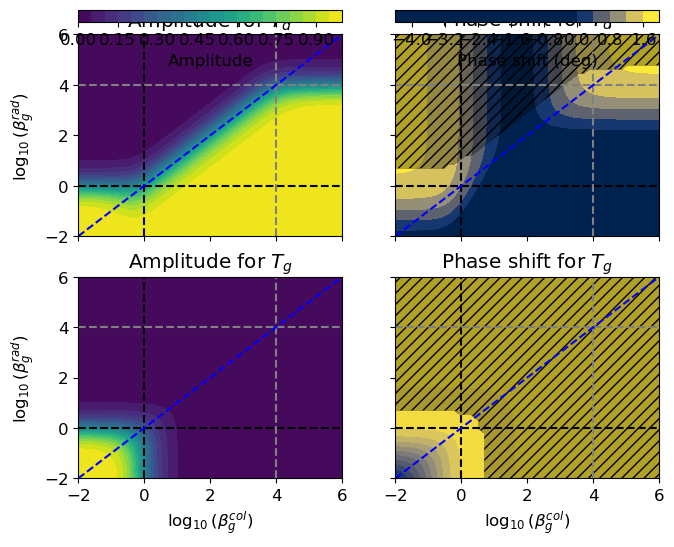

In [14]:
# python
# ...existing code...
import matplotlib.pyplot as plt
import numpy as np

plt.rc("font", size=12)
fig, axes = plt.subplots(2, 2, figsize=(7.5, 6), sharex=True, sharey=True)

# Panel 1: Amplitude for Td
im0 = axes[0, 0].contourf(
    np.log10(beta_d_grid*heat_capacity_ratio), np.log10(beta_r_grid*heat_capacity_ratio), amp_Td.T,
    levels=21, cmap='viridis', vmax=1, vmin=0
)
axes[0, 0].set_title('Amplitude for $T_d$')

# Panel 2: Phase shift for Td
im1 = axes[0, 1].contourf(
    np.log10(beta_d_grid*heat_capacity_ratio), np.log10(beta_r_grid*heat_capacity_ratio),
    np.log10(-np.rad2deg(shift_Td.T)),
    levels=int(90/m/3)+1, vmax=np.log10(90/m), vmin=0, cmap='cividis'
)
axes[0, 1].set_title('Phase shift for $T_d$')

# Panel 3: Amplitude for Tg
im2 = axes[1, 0].contourf(
    np.log10(beta_d_grid*heat_capacity_ratio), np.log10(beta_r_grid*heat_capacity_ratio), amp_Tg.T,
    levels=21, cmap='viridis', vmax=1, vmin=0
)
axes[1, 0].set_title('Amplitude for $T_g$')

# Panel 4: Phase shift for Tg
im3 = axes[1, 1].contourf(
    np.log10(beta_d_grid*heat_capacity_ratio), np.log10(beta_r_grid*heat_capacity_ratio),
    np.log10(-np.rad2deg(shift_Tg.T)),
    levels=int(90/m/3)+1, vmax=np.log10(90/m), vmin=0, cmap='cividis'
)
axes[1, 1].set_title('Phase shift for $T_g$')

for ax in axes[1, :]:
    ax.set_xlabel(r'$\log_{10}(\beta_g^{col})$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\log_{10}(\beta_g^{rad})$')

for ax in axes.flatten():
    ax.axvline(0, color='k', linestyle='--')
    ax.axhline(0, color='k', linestyle='--')
    ax.axvline(np.log10(heat_capacity_ratio), color='gray', linestyle='--')
    ax.axhline(np.log10(heat_capacity_ratio), color='gray', linestyle='--')
    ax.plot([-2, 6], [-2, 6], color='blue', linestyle='--')

# add hatch overlays (unchanged)
mask = (amp_Tg.T < 1e-1).astype(int)
ax = axes[1, 1]
ax.contourf(
    np.log10(beta_d_grid*heat_capacity_ratio), np.log10(beta_r_grid*heat_capacity_ratio), mask,
    levels=[0.5, 1.5], colors='none', hatches=['///'], alpha=0.3
)
mask = (amp_Td.T < 1e-1).astype(int)
ax = axes[0, 1]
ax.contourf(
    np.log10(beta_d_grid*heat_capacity_ratio), np.log10(beta_r_grid*heat_capacity_ratio), mask,
    levels=[0.5, 1.5], colors='none', hatches=['///'], alpha=0.3
)

# create horizontal colorbars above each column
fig.subplots_adjust(top=0.85)  # leave room at top
pad = 0.02
left_pos = axes[0, 0].get_position()
cax_left = fig.add_axes([left_pos.x0, left_pos.y1 + pad, left_pos.width, 0.02])
cb_left = fig.colorbar(im0, cax=cax_left, orientation='horizontal')
cb_left.set_label('Amplitude')

right_pos = axes[0, 1].get_position()
cax_right = fig.add_axes([right_pos.x0, right_pos.y1 + pad, right_pos.width, 0.02])
cb_right = fig.colorbar(im1, cax=cax_right, orientation='horizontal')
cb_right.set_label('Phase shift (deg)')

#plt.tight_layout()
plt.show()
# ...existing code...